In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="1"

2025-02-20 10:24:07.515197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740047047.527106  488314 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740047047.530880  488314 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [6]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)

num_stars = 10

In [7]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at al

seed = 42

df_train = df.sample(frac=0.95, random_state=seed)

df_test = df.drop(df_train.index)

In [8]:
prior_values = [0.9, 0.01, 0.26, 1.9, 11000, 0.15, 0.0001]

prior_widths = [0.01, 0.001, 0.001, 0.1, 100, 0.01, 0.0001]

tolerance = [0.001, 0.00001, 0.0001, 0.1, 1, 0.01, 0.0001]

priors = [(prior_values[i], prior_widths[i]) for i in range(len(prior_values))]

cluster_consts = {}

for key, value in zip(model_outputs.inputs, priors):
    if key not in cluster_consts:
        cluster_consts[key] = value
    else:
        cluster_consts[key].append(value)
cluster_consts

{'massini': (0.9, 0.01),
 'zini': (0.01, 0.001),
 'yini': (0.26, 0.001),
 'alphaMLT': (1.9, 0.1),
 'age': (11000, 100),
 'eta': (0.15, 0.01),
 'alphaFe': (0.0001, 0.0001)}

# Make a fake cluster

In [9]:
def fake_stars(uncs, consts = cluster_consts, obs = model_outputs.obs_dict):

    with numpyro.plate("star", 1):

        age = numpyro.sample('age', dist.Normal(consts['age'][0], consts['age'][1]))

#        massini = numpyro.sample('massini', dist.Normal(consts['massini'][0], consts['massini'][1]))
        
        tau = sample_beta('tau', 1, 0.01)

        massini = numpyro.deterministic('massini', 0.6*(age/10**4)**3.2*tau)


        zini = numpyro.sample('zini', dist.Normal(consts['zini'][0], consts['zini'][1]))

        yini = numpyro.sample('yini', dist.Normal(consts['yini'][0], consts['yini'][1]))
    
        alphaMLT = numpyro.sample('alphaMLT', dist.Normal(consts['alphaMLT'][0], consts['alphaMLT'][1]))

        

        eta = numpyro.sample('eta', dist.Normal(consts['eta'][0], consts['eta'][1]))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(consts['alphaFe'][0], consts['alphaFe'][1]))


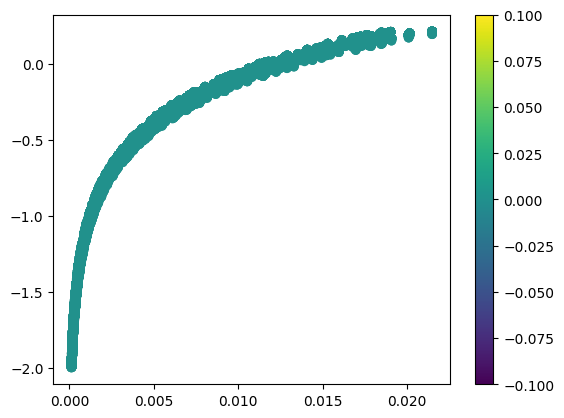

In [10]:
plt.scatter(df_test[df_test['alphaFe'] == 0]['zini'], df_test[df_test['alphaFe'] == 0]['FeH'], c = df_test[df_test['alphaFe'] == 0]['alphaFe'])
plt.colorbar()



# Prior Predictive Test

In [11]:
phys_unc = {'Teff':150, 'LPhot':4, 'numax': 10/3090, 'dnuSer':1/135, 'FeH':0.1}
#uncert = jnp.array([phys_unc[i] for i in outputs])*jnp.ones_like(jnp.array(df_obs[outputs]))

In [12]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

prior_predictive = Predictive(fake_stars, num_samples=num_stars,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )


In [13]:
cluster_df = pd.DataFrame(columns = df_test.columns)

df_test = df.drop(df_train.index)

df_test = df_test[df_test['alphaFe'] == 0]

for i in range(num_stars):
    values = [prior[j][i] for j in model_outputs.inputs]

    distance = (df_test['massini'] - values[0])**2/tolerance[0]**2 + (df_test['zini'] - values[1])**2/tolerance[1]**2 + (df_test['yini'] - values[2])**2//tolerance[2]**2 \
            + (df_test['alphaMLT'] - values[3])**2/tolerance[3]**2 + (df_test['age'] - values[4])**2/tolerance[4]**2 + (df_test['eta'] - values[5])**2/tolerance[5]**2 \
                + (df_test['alphaFe'] - values[6])**2/tolerance[6]**2

    idx_min = distance.sort_values(ascending = True).index[0]

    cluster_df.loc[i] = df_test.loc[idx_min]

    df_test = df_test.drop(index = idx_min)


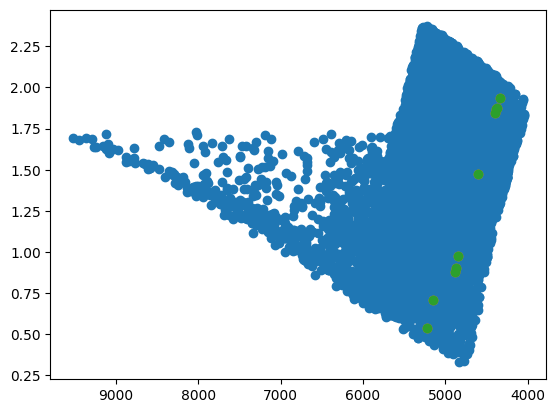

In [14]:
cluster_s = cluster_df.sample(10)

plt.scatter(df_test['Teff'], df_test['logLPhot'])
plt.scatter(cluster_df['Teff'], cluster_df['logLPhot'])
plt.scatter(cluster_s['Teff'], cluster_s['logLPhot'])

plt.gca().invert_xaxis()

In [17]:
emu_data = model_outputs(cluster_s[model_outputs.inputs])

obs_dict_values = [emu_data.T[i] for i in range(len(model_outputs.outputs))]


obs_dict = {}

for key, value in zip(model_outputs.outputs, obs_dict_values):
    if key not in obs_dict:
        obs_dict[key] = value
    else:
        obs_dict[key].append(value)

obs_dict['LPhot'] = 10**(obs_dict['logLPhot'])

np.save('./fake-cluster-observations.npy', obs_dict)

np.save('./fake-cluster-consts.npy', cluster_consts)

In [16]:
cluster_s.to_csv('fake-cluster-df.csv',)

In [286]:
cluster_s

,massini,zini,yini,alphaMLT,age,eta,alphaFe,FeH,LPhot,Teff,numax,dnuSer,logLPhot
269,1.001,0.011264,0.256816,2.285938,11458.79906,0.216211,0.0,-0.055150,35.973980,4837.731856,0.014882,0.038747,1.555988
407,0.876,0.005658,0.296156,2.031543,10821.00870,0.261145,0.0,-0.336595,29.110269,4939.220004,0.017289,0.045190,1.464046
122,1.014,0.010444,0.254119,1.831836,10631.93367,0.007544,0.0,-0.092138,8.261521,4860.961419,0.066990,0.122047,0.917060
673,1.081,0.017306,0.251667,2.293799,11138.52479,0.139801,0.0,0.133461,30.689628,4780.081377,0.018088,0.043876,1.486992
325,0.903,0.009611,0.306193,2.193408,11198.70687,0.235748,0.0,-0.096672,59.369837,4722.790461,0.007457,0.023312,1.773566
...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,1.001,0.011264,0.256816,2.285938,11518.10656,0.216211,0.0,-0.055150,79.260957,4633.662425,0.005793,0.018685,1.899059
737,1.081,0.017306,0.251667,2.293799,11188.02087,0.139801,0.0,0.133461,89.528788,4491.448128,0.004978,0.016159,1.951963
313,0.876,0.005658,0.296156,2.031543,10881.26000,0.261145,0.0,-0.336595,71.358226,4705.023693,0.005926,0.019755,1.853444
300,1.001,0.011264,0.256816,2.285938,11487.76151,0.216211,0.0,-0.055150,39.766460,4823.841719,0.013316,0.035579,1.599517


(array([15.,  0., 20., 17., 11., 10.,  9., 10.,  7.,  1.]),
 array([0.22111084, 0.23160828, 0.24210571, 0.25260315, 0.26310059,
        0.27359802, 0.28409546, 0.2945929 , 0.30509033, 0.31558777,
        0.3260852 ]),
 <BarContainer object of 10 artists>)

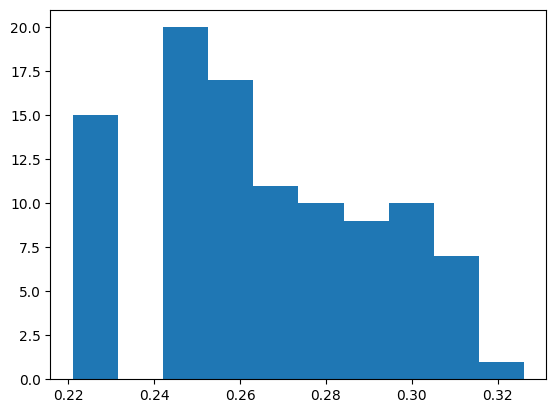

In [292]:
plt.hist(cluster_s['yini'])


(array([  5.,  12.,  60., 169., 197., 247., 199.,  73.,  28.,  10.]),
 array([0.25665444, 0.25729886, 0.25794324, 0.25858766, 0.25923207,
        0.25987649, 0.26052088, 0.26116529, 0.26180971, 0.26245409,
        0.26309851]),
 <BarContainer object of 10 artists>)

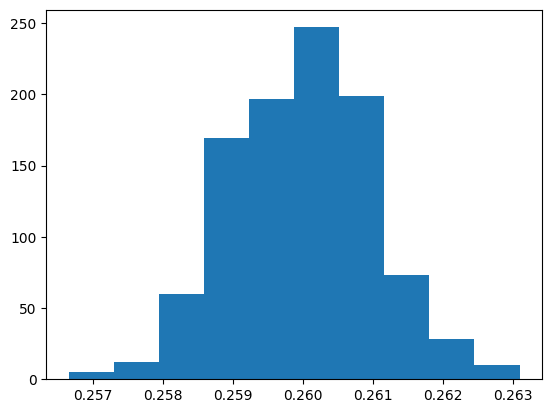

In [293]:
plt.hist(prior['yini'])